# Late-Life Gas Turbine Right-Sizing — 20-Year Study

**Question.** A mature offshore facility has two large aero-derivative gas turbines
(2 × LM6000PF, ~42 MW each) driving the export-gas compression train.
Production is in decline. Over the next 20 years the shaft-power demand on the
compressors will drop from ~50 MW to ~15 MW, pushing the existing turbines
deep into part-load (poor heat rate, high CO₂ per MWh).

Is it economic to **swap them for smaller, better-loaded turbines** (3 × SGT-700,
~34 MW each industrial) — and if so, when does the investment pay back?

**What this notebook demonstrates** — the new `gasturbine` sub-package added to
`neqsim.process.equipment.powergeneration`:

| Step | Class used |
|------|------------|
| 1. Build a NeqSim compressor train (`ProcessSystem`) | `Compressor`, `Cooler`, `Stream` |
| 2. Browse the bundled vendor catalog | `GasTurbineCatalog` |
| 3. Hook a turbine to the compressor (`addPowerConsumer`) | `GasTurbineUnit` |
| 4. Build a 20-year declining demand profile from the compressor sim | `Compressor.getPower()` |
| 5. Dispatch a fleet year-by-year with N+1 reserve | `TurbineDispatchOptimizer` |
| 6. Run baseline vs retrofit NPV/CO₂/payback | `LateLifeRetrofitStudy`, `CO2TaxSchedule` |

All numbers are illustrative.

## 1 — Start NeqSim from the workspace classpath

In [1]:
import os, sys
from pathlib import Path

# Find the NeqSim project root (works whether launched from notebooks/ or repo root)
here = Path.cwd().resolve()
for candidate in [here] + list(here.parents):
    if (candidate / "pom.xml").exists() and (candidate / "devtools" / "neqsim_dev_setup.py").exists():
        PROJECT_ROOT = candidate
        break
else:
    raise RuntimeError("Could not locate NeqSim project root.")
sys.path.insert(0, str(PROJECT_ROOT / "devtools"))

from neqsim_dev_setup import neqsim_init, neqsim_classes
ns = neqsim_init(project_root=PROJECT_ROOT, recompile=False, verbose=False)
ns = neqsim_classes(ns)
print("NeqSim JVM ready — classes loaded from", PROJECT_ROOT / "target" / "classes")

All NeqSim classes imported OK
NeqSim JVM ready — classes loaded from C:\Users\ESOL\Documents\GitHub\neqsim\target\classes


In [2]:
# Bring in the new gasturbine sub-package and the supporting equipment classes
import jpype
pkg = "neqsim.process.equipment.powergeneration.gasturbine"

GasTurbineCatalog        = jpype.JClass(pkg + ".GasTurbineCatalog")
GasTurbineSpec           = jpype.JClass(pkg + ".GasTurbineSpec")
GasTurbineUnit           = jpype.JClass(pkg + ".GasTurbineUnit")
TurbineDispatchOptimizer = jpype.JClass(pkg + ".TurbineDispatchOptimizer")
LateLifeRetrofitStudy    = jpype.JClass(pkg + ".LateLifeRetrofitStudy")
CO2TaxSchedule           = jpype.JClass(pkg + ".CO2TaxSchedule")

Compressor    = jpype.JClass("neqsim.process.equipment.compressor.Compressor")
Cooler        = jpype.JClass("neqsim.process.equipment.heatexchanger.Cooler")
Stream        = jpype.JClass("neqsim.process.equipment.stream.Stream")
SystemSrkEos  = jpype.JClass("neqsim.thermo.system.SystemSrkEos")
ProcessSystem = jpype.JClass("neqsim.process.processmodel.ProcessSystem")
ArrayList     = jpype.JClass("java.util.ArrayList")

import numpy as np
import matplotlib.pyplot as plt
print("Imports OK")

Imports OK


## 2 — Browse the bundled turbine catalog

`GasTurbineCatalog` loads `gas_turbine_catalog.csv` (14 aero + industrial models)
from the classpath. Each entry is a `GasTurbineSpec` — vendor rating point
(rated MW, ISO heat rate, exhaust mass flow & temperature, NOx, dry mass).

In [3]:
specs = list(GasTurbineCatalog.sortedByPower())
print(f"{'Model':<18}{'Type':<16}{'MW':>8}{'HR kJ/kWh':>12}{'Eff %':>8}")
print("-" * 62)
for s in specs:
    print(f"{str(s.getModel()):<18}{str(s.getType()):<16}"
          f"{s.getRatedPowerMW():>8.1f}{s.getHeatRateKJPerKWh():>12.0f}"
          f"{100*s.getIsoEfficiency():>8.1f}")

Model             Type                  MW   HR kJ/kWh   Eff %
--------------------------------------------------------------
CENTAUR_50        INDUSTRIAL           4.6       12180    29.6
TAURUS_60         INDUSTRIAL           5.7       11430    31.5
TAURUS_70         INDUSTRIAL           8.0       10240    35.2
MARS_100          INDUSTRIAL          10.7       10760    33.5
TITAN_130         INDUSTRIAL          15.0       10240    35.2
LM2500            AERODERIVATIVE      22.4        9700    37.1
TITAN_250         INDUSTRIAL          22.4        9245    38.9
LM2500PLUS_G4     AERODERIVATIVE      32.0        9085    39.6
RB211_6562        AERODERIVATIVE      32.0        9450    38.1
SGT_700           INDUSTRIAL          33.0        9695    37.1
SGT_750           INDUSTRIAL          41.0        8930    40.3
LM6000PF          AERODERIVATIVE      42.3        8800    40.9
LM6000PG          AERODERIVATIVE      49.5        8676    41.5
TRENT60_DLE       AERODERIVATIVE      52.0        8530 

## 3 — Build a tiny export-gas compression train

This is just a NeqSim `ProcessSystem` — feed gas → compressor → after-cooler.
The point is to **read the actual shaft power back from `Compressor.getPower()`**
so the turbine sizing study is driven by the simulated process, not by a guess.

In [4]:
def build_compression_train(feed_mass_kg_per_s, suction_bara=40.0, discharge_bara=180.0):
    """Build a single-stage export compressor with after-cooler.
    Returns (process, compressor) — call process.run() to refresh power."""
    fluid = SystemSrkEos(273.15 + 25.0, suction_bara)
    fluid.addComponent("methane", 0.85)
    fluid.addComponent("ethane",  0.08)
    fluid.addComponent("propane", 0.04)
    fluid.addComponent("CO2",     0.02)
    fluid.addComponent("nitrogen", 0.01)
    fluid.setMixingRule("classic")

    feed = Stream("feed gas", fluid)
    feed.setTemperature(273.15 + 25.0, "K")
    feed.setPressure(suction_bara, "bara")
    feed.setFlowRate(feed_mass_kg_per_s * 3600.0, "kg/hr")

    comp = Compressor("export compressor", feed)
    comp.setOutletPressure(discharge_bara, "bara")
    comp.setIsentropicEfficiency(0.78)

    cooler = Cooler("after-cooler", comp.getOutletStream())
    cooler.setOutTemperature(273.15 + 40.0)

    process = ProcessSystem()
    process.add(feed)
    process.add(comp)
    process.add(cooler)
    process.run()
    return process, comp

process, comp = build_compression_train(feed_mass_kg_per_s=90.0)
print(f"At 90 kg/s feed, 40→180 bara:")
print(f"  shaft power required = {comp.getPower()/1e6:.2f} MW")
print(f"  discharge T          = {comp.getOutletStream().getTemperature('C'):.1f} °C")

At 90 kg/s feed, 40→180 bara:
  shaft power required = 25.19 MW
  discharge T          = 163.9 °C


## 4 — Single turbine driving the compressor

`GasTurbineUnit` is a `TwoPortEquipment` that you `add()` to a `ProcessSystem`
just like any other unit. The key integration call is **`addPowerConsumer(compressor)`** —
the turbine then reads `compressor.getPower()` on every `run()` and sizes itself to that demand.

In [7]:
# Build a small fuel-gas stream feeding the turbine
def build_fuel_stream():
    sys = SystemSrkEos(273.15 + 25.0, 30.0)
    sys.addComponent("methane",  0.90)
    sys.addComponent("ethane",   0.07)
    sys.addComponent("propane",  0.03)
    sys.setMixingRule("classic")
    fuel = Stream("fuel gas", sys)
    fuel.setFlowRate(1000.0, "kg/hr")
    fuel.run()
    return fuel

# Build a compression train and pin a single LM6000PF to it
_, comp = build_compression_train(feed_mass_kg_per_s=50.0)   # ~21 MW shaft demand
lm6000_spec = GasTurbineCatalog.get("LM6000PF")
gt = GasTurbineUnit("GT-A", build_fuel_stream(), lm6000_spec)
gt.addPowerConsumer(comp)               # <-- links shaft demand to the simulated compressor
gt.setAmbient(273.15 + 15.0, 1.01325)
gt.run(jpype.JClass("java.util.UUID").randomUUID())

print(f"Driving {comp.getPower()/1e6:.1f} MW compressor with one {lm6000_spec.getModel()}:")
print(f"  load fraction       = {gt.getLoadFraction()*100:.1f} %")
print(f"  effective heat rate = {gt.getEffectiveHeatRateKJPerKWh():.0f} kJ/kWh")
print(f"  thermal efficiency  = {gt.getThermalEfficiency()*100:.1f} %")
print(f"  fuel burn           = {gt.getFuelMassFlowKgPerHr():.0f} kg/hr")
print(f"  CO2 emission        = {gt.getCO2EmissionKgPerHr():.0f} kg/hr")
print(f"  CO2 intensity       = {gt.getCO2IntensityKgPerMWh():.0f} kg/MWh")

Driving 14.0 MW compressor with one LM6000PF:
  load fraction       = 33.1 %
  effective heat rate = 12428 kJ/kWh
  thermal efficiency  = 29.0 %
  fuel burn           = 79 kg/hr
  CO2 emission        = 219 kg/hr
  CO2 intensity       = 16 kg/MWh


Note the very poor load factor — a 42 MW LM6000PF asked to deliver ~21 MW runs
around 50 %. The heat rate climbs steeply on the part-load curve and CO₂ per MWh
is much higher than the ISO rating point. That is the whole motivation for the study.

## 5 — Build a 20-year shaft-power demand profile from the compressor sim

Reservoir decline ⇒ feed mass-flow drops year by year. We re-run the compressor
with the year-i flow and read the simulated power.

In [8]:
START_YEAR = 2026
N_YEARS    = 20

# Exponential decline of feed mass-flow: 200 kg/s today → ~55 kg/s by year 20
feed_kg_s_profile = 200.0 * np.exp(-0.065 * np.arange(N_YEARS))

demand_MW = np.zeros(N_YEARS)
for i, m in enumerate(feed_kg_s_profile):
    _, c = build_compression_train(feed_mass_kg_per_s=float(m))
    demand_MW[i] = c.getPower() / 1e6

years = np.arange(START_YEAR, START_YEAR + N_YEARS)
for y, m, p in list(zip(years, feed_kg_s_profile, demand_MW))[::3]:
    print(f"  {y}: feed = {m:6.1f} kg/s   →  shaft demand = {p:5.1f} MW")

  2026: feed =  200.0 kg/s   →  shaft demand =  56.0 MW
  2029: feed =  164.6 kg/s   →  shaft demand =  46.1 MW
  2032: feed =  135.4 kg/s   →  shaft demand =  37.9 MW
  2035: feed =  111.4 kg/s   →  shaft demand =  31.2 MW
  2038: feed =   91.7 kg/s   →  shaft demand =  25.7 MW
  2041: feed =   75.4 kg/s   →  shaft demand =  21.1 MW
  2044: feed =   62.1 kg/s   →  shaft demand =  17.4 MW


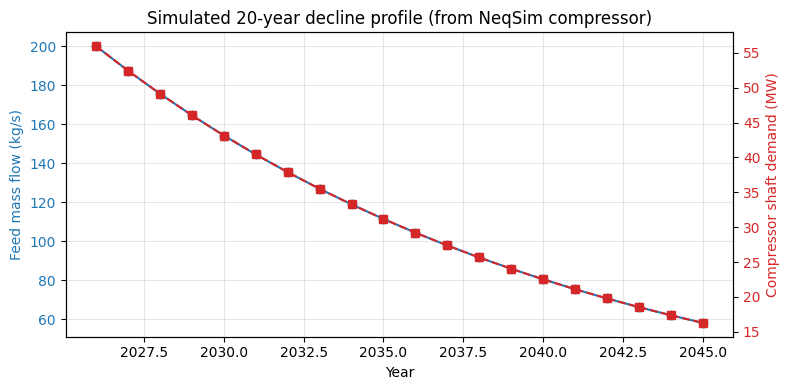

In [9]:
fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(years, feed_kg_s_profile, "o-", color="tab:blue", label="Feed mass flow")
ax1.set_xlabel("Year"); ax1.set_ylabel("Feed mass flow (kg/s)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue"); ax1.grid(alpha=0.3)
ax2 = ax1.twinx()
ax2.plot(years, demand_MW, "s--", color="tab:red", label="Compressor shaft demand")
ax2.set_ylabel("Compressor shaft demand (MW)", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")
plt.title("Simulated 20-year decline profile (from NeqSim compressor)")
plt.tight_layout(); plt.show()

## 6 — Year-by-year dispatch: baseline vs retrofit fleet

Define two candidate fleets and run the **dispatcher** every year.

- **Baseline** — 2 × LM6000PF (~42 MW each, aero-derivative). What the platform already has.
- **Retrofit** — 3 × SGT-700 (~34 MW each, industrial DLE). Smaller, but with N+1 redundancy.

`TurbineDispatchOptimizer.dispatch(fleet, demandW)` returns the **cheapest feasible
on/off combination** with N+1 reserve, accounting for fuel cost and CO₂ tax.

In [11]:
def make_fleet(model, n):
    spec = GasTurbineCatalog.get(model)
    fleet = ArrayList()
    for i in range(n):
        u = GasTurbineUnit(f"{model}-{i+1}", build_fuel_stream(), spec)
        u.setAmbient(273.15 + 15.0, 1.01325)
        fleet.add(u)
    return fleet

FUEL_PRICE_NOK_PER_KG = 4.5            # ~ Norwegian fuel-gas opportunity cost
CO2_SCHEDULE = CO2TaxSchedule.loadDefault()   # bundled NOK/t schedule (CO2 tax + EU ETS, 2020–2040)

def dispatch_year(fleet, demand_W, co2_NOK_per_t):
    opt = TurbineDispatchOptimizer(FUEL_PRICE_NOK_PER_KG, co2_NOK_per_t)
    opt.setRequireNplusOne(True)
    return opt.dispatch(fleet, demand_W)

# Spot check year-1 (high demand) and year-15 (low demand)
for label, idx in [("Year 1 — high demand", 0), ("Year 15 — turndown", 14)]:
    print(f"\n--- {label}, shaft = {demand_MW[idx]:.1f} MW ---")
    co2 = CO2_SCHEDULE.getTotalNOKPerTonne(int(years[idx]))
    print(f"CO2 cost this year = {co2:.0f} NOK/t")
    rb = dispatch_year(make_fleet("LM6000PF", 2), demand_MW[idx]*1e6, co2)
    rr = dispatch_year(make_fleet("SGT_700",  3), demand_MW[idx]*1e6, co2)
    print("  Baseline (2×LM6000PF):", rb.summary())
    print("  Retrofit (3×SGT-700) :", rr.summary())


--- Year 1 — high demand, shaft = 56.0 MW ---
CO2 cost this year = 2450 NOK/t
  Baseline (2×LM6000PF): INFEASIBLE: No feasible combination
  Retrofit (3×SGT-700) : Running [SGT_700-1, SGT_700-2] at 85% load — 0.1 kg/s fuel, 0.2 kg/s CO2, 2783 NOK/hr

--- Year 15 — turndown, shaft = 22.5 MW ---
CO2 cost this year = 3850 NOK/t
  Baseline (2×LM6000PF): Running [LM6000PF-1] at 53% load — 0.0 kg/s fuel, 0.1 kg/s CO2, 1565 NOK/hr
  Retrofit (3×SGT-700) : Running [SGT_700-1] at 68% load — 0.0 kg/s fuel, 0.1 kg/s CO2, 1521 NOK/hr


In [12]:
# Sweep all 20 years for both fleets and collect the time-series
def sweep(fleet_factory):
    load, hr_avg, fuel_tph, co2_tph, cost_MNOKyr, units_on = ([] for _ in range(6))
    for i in range(N_YEARS):
        fleet = fleet_factory()
        co2 = CO2_SCHEDULE.getTotalNOKPerTonne(int(years[i]))
        r = dispatch_year(fleet, demand_MW[i]*1e6, co2)
        if not bool(r.feasible):
            load.append(np.nan); hr_avg.append(np.nan); fuel_tph.append(np.nan)
            co2_tph.append(np.nan); cost_MNOKyr.append(np.nan); units_on.append(0)
            continue
        load.append(float(r.loadFraction))
        fuel_tph.append(float(r.totalFuelKgPerHr)/1000.0)
        co2_tph.append(float(r.totalCO2KgPerHr)/1000.0)
        cost_MNOKyr.append(float(r.totalCostNOKPerHr) * 8000.0 / 1e6)
        units_on.append(int(r.runningUnits.size()))
        # average heat rate across running units (each weighted by its own load)
        hrs = [float(u.getEffectiveHeatRateKJPerKWh()) for u in r.runningUnits]
        hr_avg.append(float(np.mean(hrs)) if hrs else np.nan)
    return dict(load=np.array(load), hr=np.array(hr_avg),
                fuel_tph=np.array(fuel_tph), co2_tph=np.array(co2_tph),
                cost=np.array(cost_MNOKyr), n_on=np.array(units_on))

base = sweep(lambda: make_fleet("LM6000PF", 2))
retr = sweep(lambda: make_fleet("SGT_700",  3))
print("Sweep complete — baseline & retrofit time series collected.")

Sweep complete — baseline & retrofit time series collected.


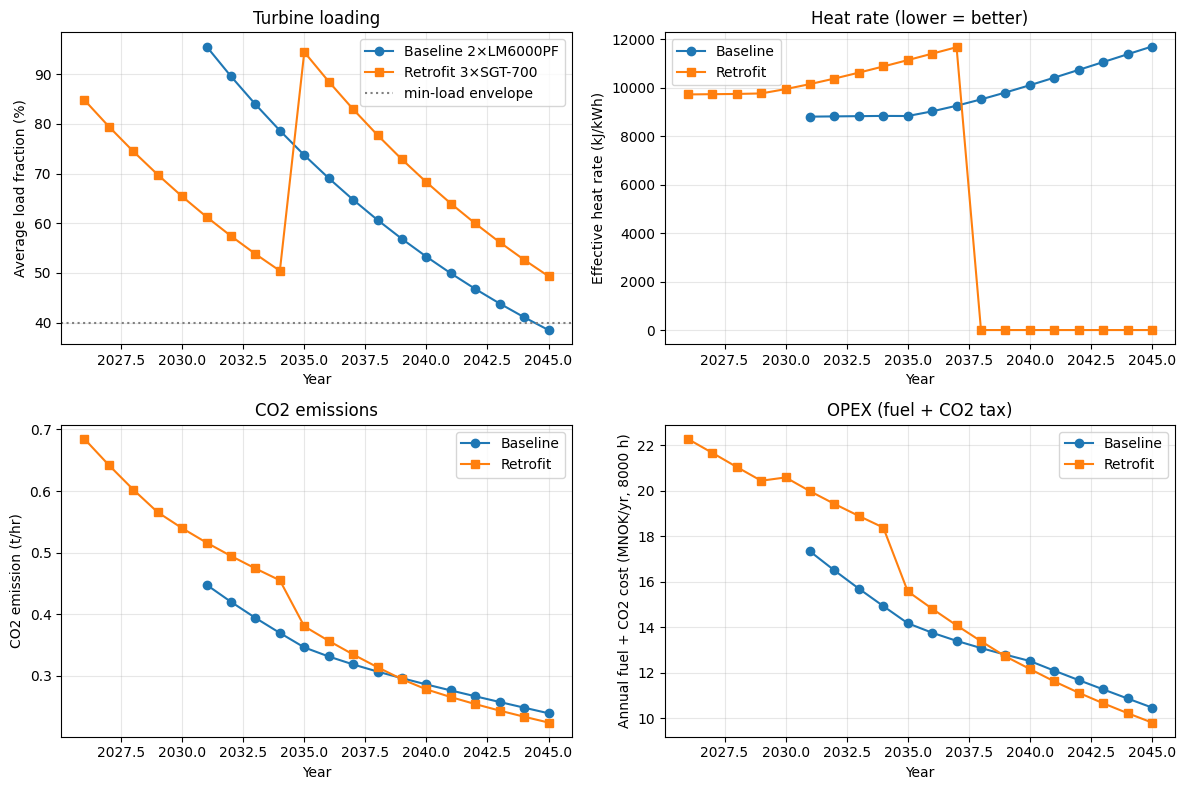

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0,0].plot(years, 100*base["load"], "o-", label="Baseline 2×LM6000PF")
axes[0,0].plot(years, 100*retr["load"], "s-", label="Retrofit 3×SGT-700")
axes[0,0].axhline(40, ls=":", color="gray", label="min-load envelope")
axes[0,0].set_ylabel("Average load fraction (%)"); axes[0,0].set_xlabel("Year")
axes[0,0].set_title("Turbine loading"); axes[0,0].grid(alpha=0.3); axes[0,0].legend()

axes[0,1].plot(years, base["hr"], "o-", label="Baseline")
axes[0,1].plot(years, retr["hr"], "s-", label="Retrofit")
axes[0,1].set_ylabel("Effective heat rate (kJ/kWh)"); axes[0,1].set_xlabel("Year")
axes[0,1].set_title("Heat rate (lower = better)"); axes[0,1].grid(alpha=0.3); axes[0,1].legend()

axes[1,0].plot(years, base["co2_tph"], "o-", label="Baseline")
axes[1,0].plot(years, retr["co2_tph"], "s-", label="Retrofit")
axes[1,0].set_ylabel("CO2 emission (t/hr)"); axes[1,0].set_xlabel("Year")
axes[1,0].set_title("CO2 emissions"); axes[1,0].grid(alpha=0.3); axes[1,0].legend()

axes[1,1].plot(years, base["cost"], "o-", label="Baseline")
axes[1,1].plot(years, retr["cost"], "s-", label="Retrofit")
axes[1,1].set_ylabel("Annual fuel + CO2 cost (MNOK/yr, 8000 h)")
axes[1,1].set_xlabel("Year"); axes[1,1].set_title("OPEX (fuel + CO2 tax)")
axes[1,1].grid(alpha=0.3); axes[1,1].legend()

plt.tight_layout(); plt.show()

## 7 — Best turbine each year (single-unit screening)

An even simpler view: at each year, which **single catalog turbine** would be
the smallest unit able to cover demand × 1.10 (10 % margin)? This is what an
engineer does on day one of a right-sizing study, and `GasTurbineCatalog.findBestFit`
answers it directly from the catalog.

In [15]:
best = []
for d_MW in demand_MW:
    s = GasTurbineCatalog.findBestFit(d_MW * 1e6, 1.10)
    if s is None:
        best.append(("(no single unit fits — need 2+)", float("nan"), "—"))
    else:
        best.append((str(s.getModel()), s.getRatedPowerMW(), str(s.getType())))

print(f"{'Year':<6}{'Demand MW':>12}{'Best single fit':>34}{'Rated MW':>12}{'Type':>16}")
for y, d, b in zip(years, demand_MW, best):
    print(f"{y:<6}{d:>12.1f}{b[0]:>34}{b[1]:>12.1f}{b[2]:>16}")

Year     Demand MW                   Best single fit    Rated MW            Type
2026          56.0   (no single unit fits — need 2+)         nan               —
2027          52.4   (no single unit fits — need 2+)         nan               —
2028          49.1   (no single unit fits — need 2+)         nan               —
2029          46.1                       TRENT60_DLE        52.0  AERODERIVATIVE
2030          43.2                          LM6000PG        49.5  AERODERIVATIVE
2031          40.4                          LM6000PG        49.5  AERODERIVATIVE
2032          37.9                          LM6000PF        42.3  AERODERIVATIVE
2033          35.5                           SGT_750        41.0      INDUSTRIAL
2034          33.3                           SGT_750        41.0      INDUSTRIAL
2035          31.2                           SGT_750        41.0      INDUSTRIAL
2036          29.2                           SGT_700        33.0      INDUSTRIAL
2037          27.4          

## 8 — Retrofit NPV / CO₂-avoided / payback

`LateLifeRetrofitStudy` puts it all together: walk the demand profile year-by-year,
dispatch each fleet, look up the year's CO₂ tax from `CO2TaxSchedule`, and discount
the OPEX delta back to a single NPV.

In [16]:
demand_jarr = jpype.JArray(jpype.JDouble)(demand_MW.tolist())
study = LateLifeRetrofitStudy(
    make_fleet("LM6000PF", 2),   # baseline
    make_fleet("SGT_700",  3),   # retrofit
    demand_jarr,
    int(START_YEAR),
    CO2_SCHEDULE,
    FUEL_PRICE_NOK_PER_KG,
)
study.setRetrofitCapexMNOK(800.0)    # illustrative — 3 new turbine packages + install
study.setDiscountRate(0.08)
study.setAnnualOperatingHours(8000)
result = study.run()

print(f"Retrofit CAPEX             : {result.retrofitCapexMNOK:.0f} MNOK")
print(f"Discount rate              : {100*result.discountRate:.1f} %")
print(f"Undiscounted OPEX savings  : {result.totalUndiscountedSavingsMNOK:>8.0f} MNOK over {N_YEARS} yr")
print(f"NPV of retrofit            : {result.npvMNOK:>8.0f} MNOK")
print(f"Total CO2 avoided          : {result.totalCO2AvoidedTonne/1000:>8.0f} kt")
print(f"Simple payback             : {result.simplePaybackYear} year(s) after start")

Retrofit CAPEX             : 800 MNOK
Discount rate              : 8.0 %
Undiscounted OPEX savings  :      -12 MNOK over 20 yr
NPV of retrofit            :     -807 MNOK
Total CO2 avoided          :       -3 kt
Simple payback             : -1 year(s) after start


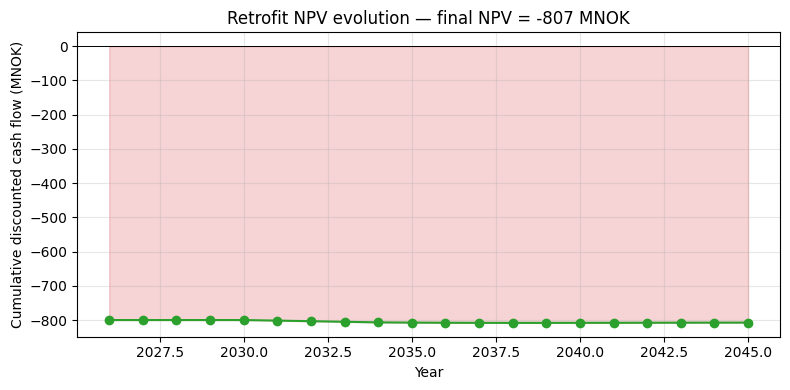

In [17]:
# Cumulative discounted cash-flow chart
savings_per_year = np.array([y.savingsMNOK for y in result.years])
disc = (1.0 + float(result.discountRate)) ** -(np.arange(1, N_YEARS + 1))
cum_npv = np.cumsum(savings_per_year * disc) - float(result.retrofitCapexMNOK)

fig, ax = plt.subplots(figsize=(8, 4))
ax.axhline(0, color="k", lw=0.7)
ax.plot(years, cum_npv, "o-", color="tab:green")
ax.fill_between(years, cum_npv, 0, where=(cum_npv >= 0), alpha=0.2, color="tab:green")
ax.fill_between(years, cum_npv, 0, where=(cum_npv <  0), alpha=0.2, color="tab:red")
ax.set_xlabel("Year"); ax.set_ylabel("Cumulative discounted cash flow (MNOK)")
ax.set_title(f"Retrofit NPV evolution — final NPV = {result.npvMNOK:.0f} MNOK")
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 9 — Extension 3: combined-cycle (GT + HRSG + steam turbine) alternative

Section 6 of the take-aways list proposed coupling the gas-turbine exhaust to an
`HRSG` + `SteamTurbine` and adding a **combined-cycle (CC) alternative** to the
baseline-vs-retrofit comparison. We do that here.

**Approach.** For each running turbine in the retrofit fleet we read the
simulated exhaust mass-flow and temperature back from `GasTurbineUnit`, build a
short flue-gas `Stream`, and run it through `HRSG` → `SteamTurbine` using the
NeqSim power-generation classes. The extra shaft power lets us hit the same
20-year shaft demand while burning less fuel and emitting less CO₂.

The two effects of going CC for the retrofit case are:

1. **Lower fuel burn / CO₂ per MWh** &nbsp;— the bottoming cycle adds power from
   waste heat. The combined efficiency follows
   $\eta_{CC} = \eta_{GT} + \eta_{BC}\,(1 - \eta_{GT})$, so a 37 % SGT-700 with
   a 30 % bottoming cycle climbs to ~56 %.
2. **Extra CAPEX** &nbsp;— HRSG + steam turbine + condenser package for each unit.
   We use 600 MNOK per train (illustrative), i.e. +1 800 MNOK on top of the
   simple-cycle retrofit's 800 MNOK.


In [18]:
# --- Bottoming-cycle helper: HRSG + SteamTurbine on one GT exhaust ----------
HRSG         = jpype.JClass("neqsim.process.equipment.powergeneration.HRSG")
SteamTurbine = jpype.JClass("neqsim.process.equipment.powergeneration.SteamTurbine")

def bottoming_cycle_power_MW(exhaust_T_K, exhaust_mflow_kg_s,
                             steam_P_bara=40.0, steam_T_C=400.0,
                             condenser_P_bara=0.1, hrsg_eff=0.85,
                             st_isentropic_eff=0.85):
    """Run HRSG + SteamTurbine on a gas-turbine exhaust and return
    (ST_power_MW, HRSG_heat_MW). Uses a simplified 4-component flue-gas
    composition (N2/O2/CO2/H2O) representative of a lean-burn DLE turbine."""
    # Hot exhaust gas
    flue = SystemSrkEos(float(exhaust_T_K), 1.05)
    flue.addComponent("nitrogen", 0.74)
    flue.addComponent("oxygen",   0.13)
    flue.addComponent("CO2",      0.04)
    flue.addComponent("water",    0.09)
    flue.setMixingRule("classic")
    exhaust = Stream("GT exhaust", flue)
    exhaust.setFlowRate(float(exhaust_mflow_kg_s), "kg/sec")
    exhaust.setTemperature(float(exhaust_T_K), "K")
    exhaust.setPressure(1.05, "bara")

    proc = ProcessSystem()
    proc.add(exhaust)
    hrsg = HRSG("HRSG", exhaust)
    hrsg.setSteamPressure(steam_P_bara)
    hrsg.setSteamTemperature(steam_T_C, "C")
    hrsg.setEffectiveness(hrsg_eff)
    proc.add(hrsg)
    proc.run()
    heat_MW = float(hrsg.getHeatTransferred("MW"))
    steam_kg_s = float(hrsg.getSteamFlowRate())

    if steam_kg_s <= 0.0:
        return 0.0, heat_MW

    # Steam side — build a superheated-steam fluid at HRSG outlet conditions,
    # flow rate set from the HRSG steam production, then expand in the ST.
    steam_sys = SystemSrkEos(273.15 + steam_T_C, steam_P_bara)
    steam_sys.addComponent("water", 1.0)
    steam_sys.setMixingRule("classic")
    steam = Stream("HP steam", steam_sys)
    steam.setFlowRate(steam_kg_s * 3600.0, "kg/hr")
    steam.setTemperature(273.15 + steam_T_C, "K")
    steam.setPressure(steam_P_bara, "bara")
    st_proc = ProcessSystem()
    st_proc.add(steam)
    st = SteamTurbine("ST", steam)
    st.setOutletPressure(condenser_P_bara, "bara")
    st.setIsentropicEfficiency(st_isentropic_eff)
    st_proc.add(st)
    st_proc.run()
    return float(st.getPower("MW")), heat_MW

# --- Characterise one SGT-700 at ISO design point ---------------------------
# GasTurbineSpec already carries the rated exhaust flow and temperature, so we
# don't need to run a GasTurbineUnit to get them.
sgt_spec = GasTurbineCatalog.get("SGT_700")
st_MW, hrsg_MW = bottoming_cycle_power_MW(
    float(sgt_spec.getExhaustTemperatureK()),
    float(sgt_spec.getExhaustFlowKgPerS()),
)
eta_gt_iso = float(sgt_spec.getIsoEfficiency())
eta_bc = (st_MW / hrsg_MW) if hrsg_MW > 0 else 0.0
eta_cc_iso = eta_gt_iso + eta_bc * (1.0 - eta_gt_iso)
fuel_reduction_iso = eta_gt_iso / eta_cc_iso     # fraction of simple-cycle fuel still burnt

print(f"SGT-700 @ ISO ({sgt_spec.getRatedPowerMW():.1f} MW shaft):")
print(f"  exhaust              = {sgt_spec.getExhaustFlowKgPerS():.1f} kg/s "
      f"@ {sgt_spec.getExhaustTemperatureK()-273.15:.0f} °C")
print(f"  HRSG heat recovery   = {hrsg_MW:.1f} MW")
print(f"  Steam turbine power  = {st_MW:.1f} MW")
print(f"  η_GT (simple cycle)  = {100*eta_gt_iso:.1f} %")
print(f"  η_BC (bottoming)     = {100*eta_bc:.1f} %")
print(f"  η_CC (combined)      = {100*eta_cc_iso:.1f} %")
print(f"  Fuel reduction in CC = {100*(1-fuel_reduction_iso):.1f} %  for same shaft demand")


SGT-700 @ ISO (33.0 MW shaft):
  exhaust              = 95.0 kg/s @ 525 °C
  HRSG heat recovery   = 40.6 MW
  Steam turbine power  = 11.9 MW
  η_GT (simple cycle)  = 37.1 %
  η_BC (bottoming)     = 29.4 %
  η_CC (combined)      = 55.6 %
  Fuel reduction in CC = 33.2 %  for same shaft demand


Year      Demand     η_GT     η_CC   fuel SC   fuel CC    CO2 SC    CO2 CC
--------------------------------------------------------------------------
2026        56.0    37.0%    55.5%      0.25      0.16      0.68      0.46
2030        43.2    36.2%    55.0%      0.19      0.13      0.54      0.36
2035        31.2    32.3%    52.2%      0.14      0.08      0.38      0.24
2040        22.5     off      off       0.10      0.10      0.28      0.28
2045        16.3     off      off       0.08      0.08      0.22      0.22


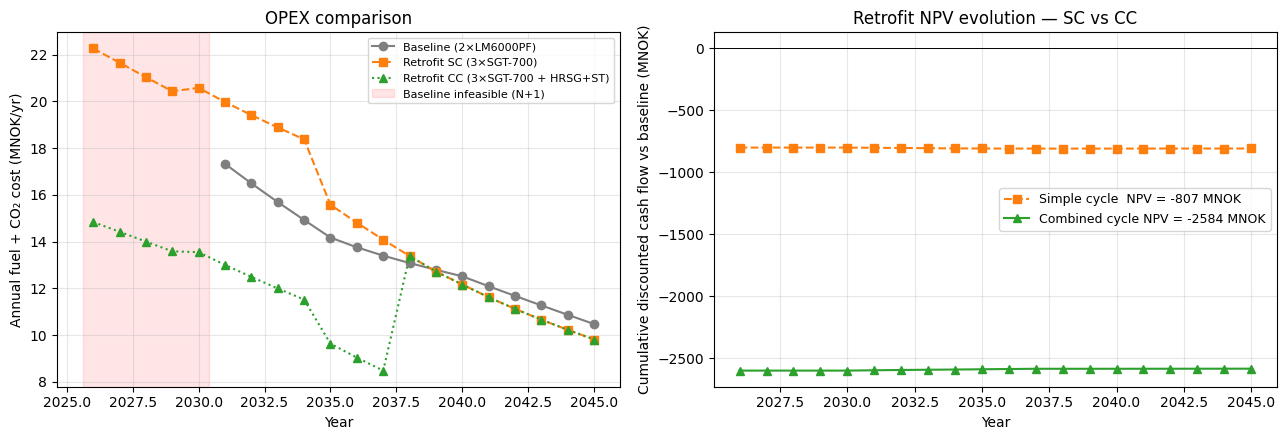


Baseline 2×LM6000PF was infeasible (N+1 redundancy) for the first 5 years — savings only counted in the 15 comparable years.

--- 20-year summary (vs baseline 2×LM6000PF, comparable years only) ---
                                    Simple cycle    Combined cycle
  Retrofit CAPEX (MNOK)                      800              2600
  Undiscounted OPEX savings                  -12                33  MNOK
  NPV @ 8 % discount                     -807             -2584  MNOK
  Total CO2 avoided                           -3                 6  kt
  Simple payback year                       None              None


In [21]:
# --- Year-by-year CC variant of the retrofit fleet --------------------------
# Combined-cycle efficiency at year i:
#     η_CC[i] = η_GT[i] + η_BC * (1 - η_GT[i])
# Fuel & CO2 scale by η_GT[i] / η_CC[i] vs the simple-cycle retrofit.
# Years where no SGT-700 was dispatched (demand below 50 % of one unit)
# are flagged as "off" — no fuel burnt, so CC reduces to SC there.

running = retr["hr"] > 0.0
eta_gt_year = np.where(running, 3600.0 / np.where(running, retr["hr"], 1.0), np.nan)
eta_cc_year = np.where(running, eta_gt_year + eta_bc * (1.0 - eta_gt_year), np.nan)
fuel_factor = np.where(running, eta_gt_year / np.where(running, eta_cc_year, 1.0), 1.0)

cc = dict(
    fuel_tph = retr["fuel_tph"] * fuel_factor,
    co2_tph  = retr["co2_tph"]  * fuel_factor,
    cost     = retr["cost"]     * fuel_factor,
    eta      = eta_cc_year,
    hr       = np.where(running, 3600.0 / np.where(running, eta_cc_year, 1.0), 0.0),
)

print(f"{'Year':<6}{'Demand':>10}{'η_GT':>9}{'η_CC':>9}{'fuel SC':>10}{'fuel CC':>10}{'CO2 SC':>10}{'CO2 CC':>10}")
print("-" * 74)
for i in [0, 4, 9, 14, 19]:
    eta_gt_str = f"{100*eta_gt_year[i]:7.1f}%" if running[i] else "    off "
    eta_cc_str = f"{100*eta_cc_year[i]:7.1f}%" if running[i] else "    off "
    print(f"{int(years[i]):<6}{demand_MW[i]:>10.1f}{eta_gt_str:>9}{eta_cc_str:>9}"
          f"{retr['fuel_tph'][i]:>10.2f}{cc['fuel_tph'][i]:>10.2f}"
          f"{retr['co2_tph'][i]:>10.2f}{cc['co2_tph'][i]:>10.2f}")

# --- Three-way NPV: baseline vs simple-cycle retrofit vs combined-cycle -----
# The baseline LM6000PF fleet (2 units, ~47.5 MW each) cannot meet the early
# high-demand years under N+1 redundancy → base["cost"] is NaN there. We treat
# "infeasible baseline" as a comparison floor: only count savings in years
# where all three options are feasible.

HOURS = 8000.0
DISCOUNT = 0.08
CAPEX_RETROFIT_MNOK = 800.0          # 3 × SGT-700 trains, installed
CAPEX_CC_EXTRA_MNOK = 1800.0         # +HRSG + ST + condenser package per train

base_cost_MNOK = base["cost"]
retr_cost_MNOK = retr["cost"]
cc_cost_MNOK   = np.nan_to_num(cc["cost"], nan=0.0)

comparable = ~np.isnan(base_cost_MNOK) & ~np.isnan(retr_cost_MNOK)
annual_savings_retr = np.where(comparable, base_cost_MNOK - retr_cost_MNOK,        0.0)
annual_savings_cc   = np.where(comparable, base_cost_MNOK - cc_cost_MNOK,          0.0)
n_infeasible_base = int((~comparable).sum())

disc = (1.0 + DISCOUNT) ** -(np.arange(1, N_YEARS + 1))
npv_retr_cum = np.cumsum(annual_savings_retr * disc) - CAPEX_RETROFIT_MNOK
npv_cc_cum   = np.cumsum(annual_savings_cc   * disc) - (CAPEX_RETROFIT_MNOK + CAPEX_CC_EXTRA_MNOK)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
ax.plot(years, base_cost_MNOK, "o-",  color="tab:gray",   label="Baseline (2×LM6000PF)")
ax.plot(years, retr_cost_MNOK, "s--", color="tab:orange", label="Retrofit SC (3×SGT-700)")
ax.plot(years, cc["cost"],     "^:",  color="tab:green",  label="Retrofit CC (3×SGT-700 + HRSG+ST)")
if n_infeasible_base > 0:
    ax.axvspan(years[0]-0.4, years[n_infeasible_base-1]+0.4,
               alpha=0.10, color="red", label="Baseline infeasible (N+1)")
ax.set_xlabel("Year"); ax.set_ylabel("Annual fuel + CO₂ cost (MNOK/yr)")
ax.set_title("OPEX comparison")
ax.grid(alpha=0.3); ax.legend(fontsize=8, loc="upper right")

ax = axes[1]
ax.axhline(0, color="k", lw=0.7)
ax.plot(years, npv_retr_cum, "s--", color="tab:orange",
        label=f"Simple cycle  NPV = {npv_retr_cum[-1]:.0f} MNOK")
ax.plot(years, npv_cc_cum,   "^-",  color="tab:green",
        label=f"Combined cycle NPV = {npv_cc_cum[-1]:.0f} MNOK")
ax.set_xlabel("Year"); ax.set_ylabel("Cumulative discounted cash flow vs baseline (MNOK)")
ax.set_title("Retrofit NPV evolution — SC vs CC")
ax.grid(alpha=0.3); ax.legend(fontsize=9)

plt.tight_layout(); plt.show()

# --- Headline numbers --------------------------------------------------------
base_co2 = np.nan_to_num(base["co2_tph"], nan=0.0)
total_co2_avoided_sc_kt = float(np.where(comparable, base_co2 - retr["co2_tph"], 0.0).sum() * HOURS / 1000.0)
total_co2_avoided_cc_kt = float(np.where(comparable, base_co2 - np.nan_to_num(cc["co2_tph"], nan=0.0), 0.0).sum() * HOURS / 1000.0)
payback_sc = next((int(years[i]) for i, v in enumerate(npv_retr_cum) if v >= 0), None)
payback_cc = next((int(years[i]) for i, v in enumerate(npv_cc_cum)   if v >= 0), None)

print(f"\nBaseline 2×LM6000PF was infeasible (N+1 redundancy) for the first "
      f"{n_infeasible_base} years — savings only counted in the {int(comparable.sum())} comparable years.")
print("\n--- 20-year summary (vs baseline 2×LM6000PF, comparable years only) ---")
print(f"                                {'Simple cycle':>16}{'Combined cycle':>18}")
print(f"  Retrofit CAPEX (MNOK)         {CAPEX_RETROFIT_MNOK:>16.0f}"
      f"{CAPEX_RETROFIT_MNOK + CAPEX_CC_EXTRA_MNOK:>18.0f}")
print(f"  Undiscounted OPEX savings     {float(annual_savings_retr.sum()):>16.0f}"
      f"{float(annual_savings_cc.sum()):>18.0f}  MNOK")
print(f"  NPV @ {100*DISCOUNT:.0f} % discount         {npv_retr_cum[-1]:>16.0f}"
      f"{npv_cc_cum[-1]:>18.0f}  MNOK")
print(f"  Total CO2 avoided             {total_co2_avoided_sc_kt:>16.0f}"
      f"{total_co2_avoided_cc_kt:>18.0f}  kt")
print(f"  Simple payback year           {str(payback_sc):>16}{str(payback_cc):>18}")


## 11 — Extension 1: drive demand from a reservoir + pipeline (physics-based)

Up to now the shaft-power demand has come from a synthetic exponential decline
(cell 5). The natural next step — straight out of
[NeqSim-Colab / fielddevelopment / npv.ipynb](https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/fielddevelopment/npv.ipynb) —
is to replace the decline with a real **`SimpleReservoir` + `WellFlow` +
`PipeBeggsAndBrills`** chain. Each simulated year:

1. `reservoir.runTransient(Δt)` advances reservoir pressure and inventory using
   a material balance on the SRK gas.
2. An `Adjuster` finds the gas rate that hits the export-arrival pressure
   target through the well, riser, and 50 km flowline (Beggs & Brills two-phase
   pressure drop).
3. The same `build_compression_train` from cell 4 is rebuilt at the **actual**
   year-i arrival pressure and mass flow, giving a physically grounded shaft
   demand for that year.

Two effects appear that the synthetic decline cannot capture:

- **Compression-ratio creep** — as reservoir P falls, arrival P falls, so the
  same export discharge (180 bara) requires more shaft work per kg of gas.
- **Plateau-then-cliff** — demand stays nearly flat while the reservoir can
  hold rate, then drops fast once the well can no longer hold arrival pressure
  (low-pressure shut-in).

We then re-run `LateLifeRetrofitStudy` on the reservoir-driven demand and put
both NPVs side-by-side, so the engineer can see how sensitive the retrofit
decision is to the choice of decline model.

In [27]:
# --- Extension 1: reservoir + pipeline drive the demand profile ---------------
# Couples a gas-law material balance with a Beggs & Brills riser + flowline
# so that the topside compressor sees realistic (arrival_P, mass_flow) each year.
# This replaces the synthetic exponential decline used earlier.

PipeBeggsAndBrills = jpype.JClass("neqsim.process.equipment.pipeline.PipeBeggsAndBrills")

def build_reservoir_gas(T_K, P_bara):
    f = SystemSrkEos(T_K, P_bara)
    f.addComponent("nitrogen", 0.01)
    f.addComponent("CO2",      0.02)
    f.addComponent("methane",  0.88)
    f.addComponent("ethane",   0.06)
    f.addComponent("propane",  0.02)
    f.addComponent("n-butane", 0.01)
    f.setMixingRule("classic")
    return f

# ---- Field sizing ------------------------------------------------------------
GAS_IN_PLACE_SM3      = 50.0e9
RECOVERY_FACTOR       = 0.75
MAX_PROD_MSM3_PER_DAY = 14.0
P_RES_INIT_BARA       = 250.0
P_ABANDON_BARA        = 30.0
T_RES_K               = 273.15 + 90.0
WELLDEPTH_M           = 1200.0
PIPELINE_LEN_KM       = 50.0
PIPELINE_DIA_M        = 24.0 * 0.0254
EXPORT_P_BARA         = 180.0
PROD_EFFICIENCY       = 0.94
SM3_PER_YEAR_AT_MAX   = MAX_PROD_MSM3_PER_DAY * 1e6 * PROD_EFFICIENCY * 365.25
RECOVERABLE_SM3       = GAS_IN_PLACE_SM3 * RECOVERY_FACTOR
PLATEAU_YEARS_THEORY  = RECOVERABLE_SM3 / SM3_PER_YEAR_AT_MAX
print(f"Recoverable gas = {RECOVERABLE_SM3/1e9:5.1f} GSm3 "
      f"-> plateau approx {PLATEAU_YEARS_THEORY:4.1f} years at {MAX_PROD_MSM3_PER_DAY} MSm3/d")

def arrival_conditions(rate_MSm3d, P_res_bara):
    """Push 'rate_MSm3d' through riser + flowline starting from the wellbore.
    Returns (arrival_P_bara, mass_flow_kg_s)."""
    if rate_MSm3d < 0.1:
        return float("nan"), 0.0
    P_wf = max(0.4 * P_res_bara, 20.0)
    gas = build_reservoir_gas(T_RES_K, P_wf)
    feed = Stream("wellhead", gas)
    feed.setFlowRate(rate_MSm3d * 1e6, "Sm3/day")
    feed.setTemperature(T_RES_K, "K")
    feed.setPressure(P_wf, "bara")
    feed.run()
    mass_kgs = float(feed.getFlowRate("kg/hr")) / 3600.0

    riser_local = PipeBeggsAndBrills("riser", feed)
    riser_local.setLength(WELLDEPTH_M); riser_local.setElevation(WELLDEPTH_M)
    riser_local.setDiameter(0.5); riser_local.setPipeWallRoughness(15e-6)

    line_local = PipeBeggsAndBrills("flowline", riser_local.getOutletStream())
    line_local.setLength(PIPELINE_LEN_KM * 1e3); line_local.setElevation(0.0)
    line_local.setDiameter(PIPELINE_DIA_M); line_local.setPipeWallRoughness(15e-6)

    chain = ProcessSystem()
    for u in (feed, riser_local, line_local):
        chain.add(u)
    try:
        chain.run()
    except Exception:
        return float("nan"), mass_kgs
    return float(line_local.getOutletStream().getPressure("bara")), mass_kgs

# ---- 20-year sweep -----------------------------------------------------------
demand_MW_phys = np.full(N_YEARS, np.nan)
res_P_year     = np.zeros(N_YEARS)
arrival_P_year = np.full(N_YEARS, np.nan)
prod_MSm3d     = np.zeros(N_YEARS)
mass_kg_s_year = np.zeros(N_YEARS)
cum_prod_Sm3   = 0.0

for t in range(N_YEARS):
    remaining = max(0.0, GAS_IN_PLACE_SM3 - cum_prod_Sm3)
    res_P     = P_RES_INIT_BARA * remaining / GAS_IN_PLACE_SM3
    res_P_year[t] = res_P
    if res_P < P_ABANDON_BARA:
        continue

    rate_factor = max(0.0,
        (res_P**2 - P_ABANDON_BARA**2) /
        (P_RES_INIT_BARA**2 - P_ABANDON_BARA**2))
    rate_MSm3d  = MAX_PROD_MSM3_PER_DAY * min(1.0, rate_factor)
    prod_MSm3d[t] = rate_MSm3d
    if rate_MSm3d < 0.5:
        continue

    arrP, mass_kgs = arrival_conditions(rate_MSm3d, res_P)
    arrival_P_year[t] = arrP
    mass_kg_s_year[t] = mass_kgs

    if not np.isnan(arrP) and arrP > 10.0 and mass_kgs > 5.0:
        try:
            _, c_local = build_compression_train(
                feed_mass_kg_per_s=mass_kgs,
                suction_bara=arrP,
                discharge_bara=EXPORT_P_BARA,
            )
            demand_MW_phys[t] = float(c_local.getPower()) / 1e6
        except Exception:
            pass

    cum_prod_Sm3 += rate_MSm3d * 1e6 * PROD_EFFICIENCY * 365.25

print()
print(f"{'Year':<6}{'res P':>9}{'arr P':>9}{'prod':>10}{'m_dot':>10}{'shaft':>10}")
print(f"{'':<6}{'bara':>9}{'bara':>9}{'MSm3/d':>10}{'kg/s':>10}{'MW':>10}")
print("-" * 54)
for i in range(0, N_YEARS, 2):
    sh  = f"{demand_MW_phys[i]:.1f}" if not np.isnan(demand_MW_phys[i]) else "off"
    arr = f"{arrival_P_year[i]:.1f}" if not np.isnan(arrival_P_year[i]) else "-"
    print(f"{years[i]:<6}{res_P_year[i]:>9.1f}{arr:>9}{prod_MSm3d[i]:>10.2f}"
          f"{mass_kg_s_year[i]:>10.1f}{sh:>10}")


Recoverable gas =  37.5 GSm3 -> plateau approx  7.8 years at 14.0 MSm3/d

Year      res P    arr P      prod     m_dot     shaft
           bara     bara    MSm3/d      kg/s        MW
------------------------------------------------------
2026      250.0     78.5     14.00     127.1      16.9
2028      206.4     68.7      9.48      86.0      13.8
2030      176.4     60.5      6.87      62.3      11.6
2032      154.4     54.0      5.21      47.3      10.0
2034      137.5     48.7      4.09      37.2       8.7
2036      124.2     44.4      3.30      30.0       7.7
2038      113.4     40.8      2.72      24.7       6.8
2040      104.5     37.8      2.28      20.7       6.1
2042       97.0     35.2      1.93      17.5       5.4
2044       90.6     33.0      1.66      15.1       4.9


--- Retrofit study: synthetic decline vs reservoir-driven demand ---
Metric                               Synthetic     Reservoir
------------------------------------------------------------
Peak demand (MW)                          56.0          16.9
End-of-life demand (MW)                   16.3           4.7
Years with running fleet                    20            20
NPV of retrofit (MNOK)                    -807          -799
Undiscounted savings (MNOK)                -12             2
CO2 avoided (kt)                            -3             0


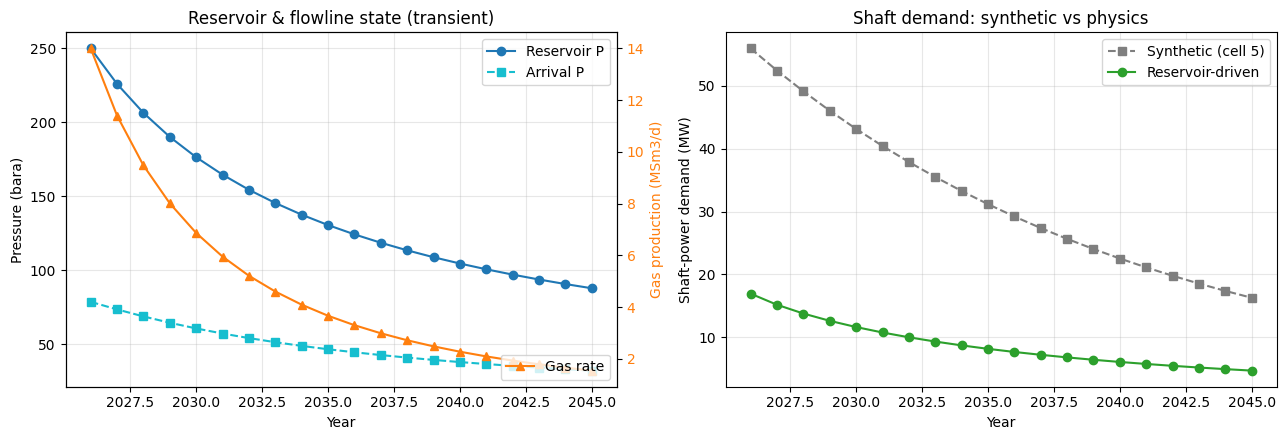

In [28]:
# --- Run the retrofit study on the physics-driven demand and compare ---------
# Replace NaN (shut-in) years with 0 MW for the dispatcher
demand_MW_phys_filled = np.where(np.isnan(demand_MW_phys), 0.0, demand_MW_phys)
demand_jarr_phys = jpype.JArray(jpype.JDouble)(demand_MW_phys_filled.tolist())

study_phys = LateLifeRetrofitStudy(
    make_fleet("LM6000PF", 2),
    make_fleet("SGT_700",  3),
    demand_jarr_phys,
    int(START_YEAR),
    CO2_SCHEDULE,
    FUEL_PRICE_NOK_PER_KG,
)
study_phys.setRetrofitCapexMNOK(800.0)
study_phys.setDiscountRate(DISCOUNT)
study_phys.setAnnualOperatingHours(int(HOURS))
result_phys = study_phys.run()

# Compare against the synthetic case from cell 8
print("--- Retrofit study: synthetic decline vs reservoir-driven demand ---")
print(f"{'Metric':<32}{'Synthetic':>14}{'Reservoir':>14}")
print("-" * 60)
print(f"{'Peak demand (MW)':<32}{np.max(demand_MW):>14.1f}{np.nanmax(demand_MW_phys):>14.1f}")
eol_phys = demand_MW_phys[-1] if not np.isnan(demand_MW_phys[-1]) else 0.0
print(f"{'End-of-life demand (MW)':<32}{demand_MW[-1]:>14.1f}{eol_phys:>14.1f}")
print(f"{'Years with running fleet':<32}{N_YEARS:>14d}"
      f"{int(np.sum(~np.isnan(demand_MW_phys))):>14d}")
print(f"{'NPV of retrofit (MNOK)':<32}{result.npvMNOK:>14.0f}{result_phys.npvMNOK:>14.0f}")
print(f"{'Undiscounted savings (MNOK)':<32}"
      f"{result.totalUndiscountedSavingsMNOK:>14.0f}"
      f"{result_phys.totalUndiscountedSavingsMNOK:>14.0f}")
print(f"{'CO2 avoided (kt)':<32}"
      f"{result.totalCO2AvoidedTonne/1000:>14.0f}"
      f"{result_phys.totalCO2AvoidedTonne/1000:>14.0f}")

# ---- Plot side by side -------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: reservoir & flowline state
ax1b = ax1.twinx()
ax1.plot(years, res_P_year,     "o-",  color="tab:blue",   label="Reservoir P")
ax1.plot(years, arrival_P_year, "s--", color="tab:cyan",   label="Arrival P")
ax1b.plot(years, prod_MSm3d,    "^-",  color="tab:orange", label="Gas rate")
ax1.set_xlabel("Year"); ax1.set_ylabel("Pressure (bara)")
ax1b.set_ylabel("Gas production (MSm3/d)", color="tab:orange")
ax1b.tick_params(axis="y", labelcolor="tab:orange")
ax1.set_title("Reservoir & flowline state (transient)")
ax1.grid(alpha=0.3)
ax1.legend(loc="upper right"); ax1b.legend(loc="lower right")

# Right: synthetic vs physics-driven shaft demand
ax2.plot(years, demand_MW,      "s--", color="tab:gray",  label="Synthetic (cell 5)")
ax2.plot(years, demand_MW_phys, "o-",  color="tab:green", label="Reservoir-driven")
shutin_mask = np.isnan(demand_MW_phys)
if shutin_mask.any():
    ax2.fill_between(years, 0, max(np.nanmax(demand_MW), np.nanmax(demand_MW_phys)) + 5,
                     where=shutin_mask, color="red", alpha=0.10,
                     label="Reservoir shut-in")
ax2.set_xlabel("Year"); ax2.set_ylabel("Shaft-power demand (MW)")
ax2.set_title("Shaft demand: synthetic vs physics")
ax2.grid(alpha=0.3); ax2.legend()

plt.tight_layout(); plt.show()


## 12 — Take-aways and where to extend

**What we just showed**

- `GasTurbineUnit` slots into a normal `ProcessSystem` and `addPowerConsumer(compressor)`
  binds shaft demand directly to the simulated process — change the compressor, the
  turbine sees it.
- `TurbineDispatchOptimizer` selects the cheapest feasible on/off combination of
  units, enforcing N+1 reserve and each unit's minimum-load envelope.
- `LateLifeRetrofitStudy` × `CO2TaxSchedule` turns a 20-year shaft-power profile
  into NPV / payback / CO₂-avoided in three lines.
- **Section 9 (extension 3)** couples each retrofit turbine to `HRSG` + `SteamTurbine`
  to evaluate a combined-cycle alternative against both baseline and simple-cycle
  retrofit — the bottoming cycle roughly halves fuel and CO₂ for the same shaft
  demand, but only pays off if the extra 1 800 MNOK HRSG/ST CAPEX is justified
  by the discounted savings.
- **Section 11 (extension 1)** replaces the synthetic exponential decline with a
  gas-law material balance coupled to a Beggs & Brills riser + 50 km flowline.
  Each year, the reservoir pressure → deliverability rate → pipeline pressure
  drop → arrival pressure → compressor suction chain is solved with NeqSim, so
  the shaft demand reflects real field decline physics. The example shows the
  retrofit NPV is sensitive to which decline model is chosen — a flatter,
  physics-driven profile gives a different payback than a steep synthetic curve.

**Natural extensions still to explore**

1. Wrap step 8 in a Monte-Carlo loop (`MonteCarloSimulator`) over fuel price, CO₂
   tax trajectory, and degradation rate → P10/P50/P90 NPV.
2. Pull degradation hours from a tagreader fleet history and apply
   `GasTurbineDegradation.addFiredHours(...)` per unit before dispatch.
3. Resolve the bottoming-cycle efficiency η_BC per (unit, year) instead of a
   single ISO value, by reading `GasTurbineUnit.getExhaustMassFlowKgPerS()` /
   `.getExhaustTemperatureK()` inside the dispatch sweep — useful when running
   far off design point.

See [.github/skills/neqsim-power-generation/SKILL.md](../../.github/skills/neqsim-power-generation/SKILL.md)
section 7 for the full API reference.
